Found Synapse note file: E:\resp_test_data\nasal_test-241017-143820\Notes.txt
read from t=0s to t=553.14s


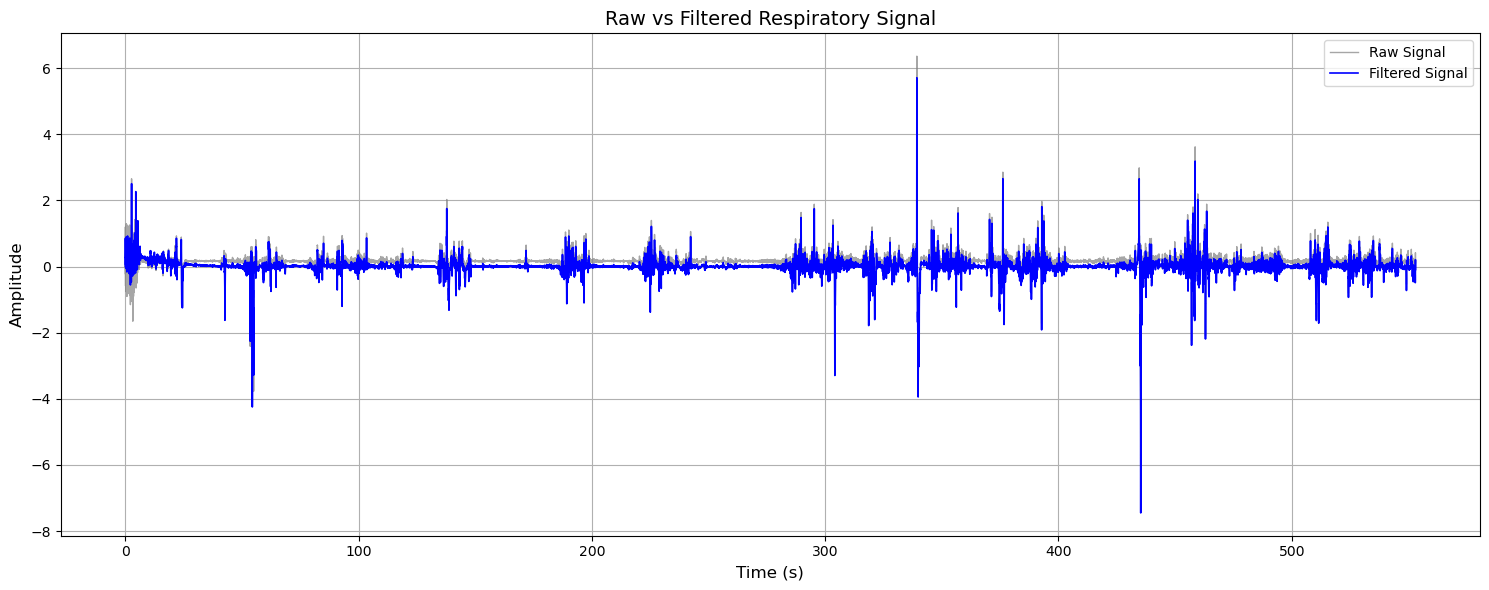

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import neurokit2 as nk
import tdt

# Load the TDT block
tdt_file_path = r"E:\resp_test_data\nasal_test-241017-143820"
data = tdt.read_block(tdt_file_path)

# Extract respiratory signal
rsp_signal = data.streams['Resp'].data  # Adjust 'Resp' to match your stream name
srate = data.streams['Resp'].fs  # Sampling rate (Hz)
total_duration = len(rsp_signal) / srate  # Total duration in seconds
time_array = np.linspace(0, total_duration, len(rsp_signal))

# Smooth the respiratory signal
rsp_cleaned = nk.signal_filter(
    rsp_signal,
    lowcut=0.01,   # Low cutoff frequency (Hz)
    highcut=20,   # High cutoff frequency (Hz)
    method="butterworth",  # Filtering method
    sampling_rate=srate,   # Sampling rate of the signal
    order=4                # Filter order
)

# Plot raw and filtered signals
plt.figure(figsize=(15, 6))
plt.plot(time_array, rsp_signal, label="Raw Signal", color="gray", alpha=0.7, linewidth=1)
plt.plot(time_array, rsp_cleaned, label="Filtered Signal", color="blue", linewidth=1.2)
plt.xlabel("Time (s)", fontsize=12)
plt.ylabel("Amplitude", fontsize=12)
plt.title("Raw vs Filtered Respiratory Signal", fontsize=14)
plt.legend(loc="upper right")
plt.grid(True)
plt.tight_layout()
plt.show()


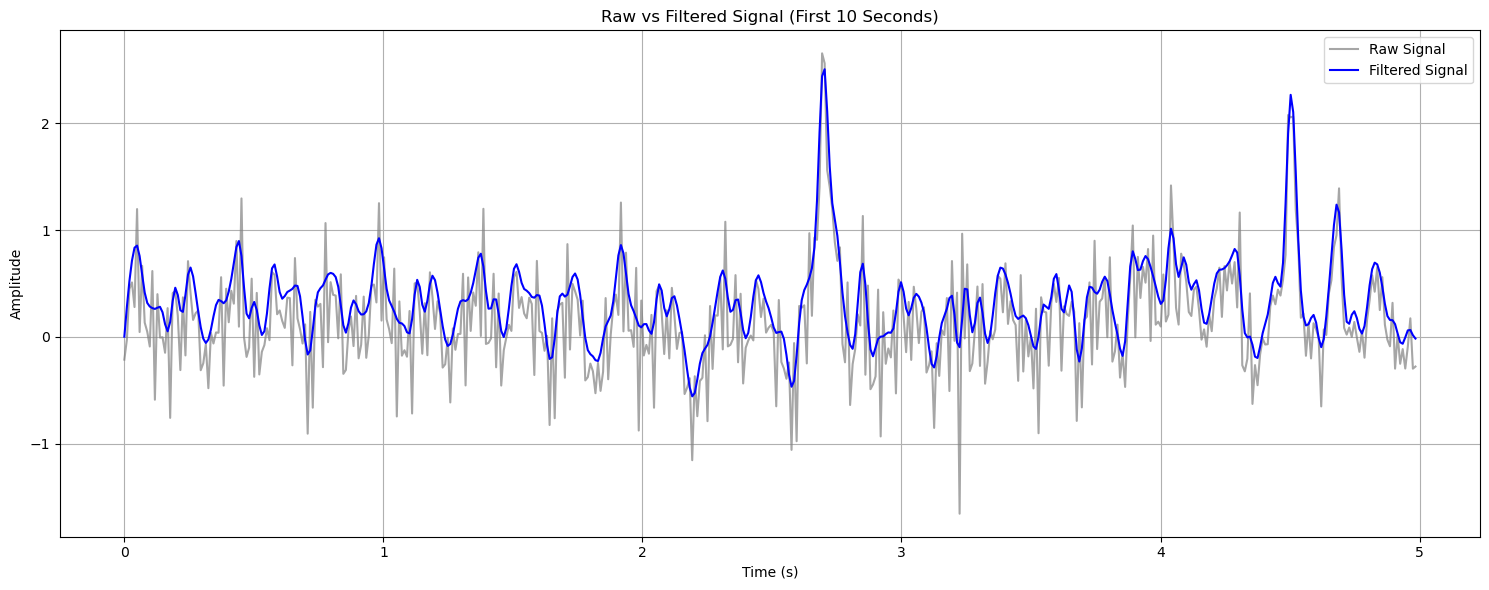

In [6]:
plt.figure(figsize=(15, 6))
plt.plot(time_array[:int(srate*5)], rsp_signal[:int(srate*5)], label="Raw Signal", color="gray", alpha=0.7)
plt.plot(time_array[:int(srate*5)], rsp_cleaned[:int(srate*5)], label="Filtered Signal", color="blue")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Raw vs Filtered Signal (First 10 Seconds)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import neurokit2 as nk
import tdt

# Load the TDT block
tdt_file_path = r"E:\resp_test_data\nasal_test-241017-143820"
data = tdt.read_block(tdt_file_path)

# Extract respiratory signal
rsp_signal = data.streams['Resp'].data  # Adjust 'Resp' to match your stream name
srate = data.streams['Resp'].fs  # Sampling rate (Hz)
total_duration = len(rsp_signal) / srate  # Total duration in seconds
time_array = np.linspace(0, total_duration, len(rsp_signal))

# Smooth the respiratory signal
rsp_cleaned = nk.signal_filter(
    rsp_signal,
    lowcut=0.1,   # Low cutoff frequency (Hz)
    highcut=20,   # High cutoff frequency (Hz)
    method="butterworth",  # Filtering method
    sampling_rate=srate,   # Sampling rate of the signal
    order=4                # Filter order
)

# Chunk size (10 seconds)
chunk_size = int(5 * srate)  # Number of samples per 10-second chunk
num_chunks = len(rsp_signal) // chunk_size  # Total number of full chunks

# Plot each chunk
for i in range(num_chunks):
    start_idx = i * chunk_size
    end_idx = start_idx + chunk_size

    # Get the time and signal for the current chunk
    chunk_time = time_array[start_idx:end_idx]
    chunk_raw = rsp_signal[start_idx:end_idx]
    chunk_filtered = rsp_cleaned[start_idx:end_idx]

    # Plot the current chunk
    plt.figure(figsize=(15, 6))
    plt.plot(chunk_time, chunk_raw, label="Raw Signal", color="gray", alpha=0.7, linewidth=1)
    plt.plot(chunk_time, chunk_filtered, label="Filtered Signal", color="blue", linewidth=1.2)
    plt.xlabel("Time (s)", fontsize=12)
    plt.ylabel("Amplitude", fontsize=12)
    plt.title(f"Raw vs Filtered Respiratory Signal (Chunk {i+1})", fontsize=14)
    plt.legend(loc="upper right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


Found Synapse note file: E:\resp_test_data\nasal_test-241017-143820\Notes.txt
read from t=0s to t=553.14s


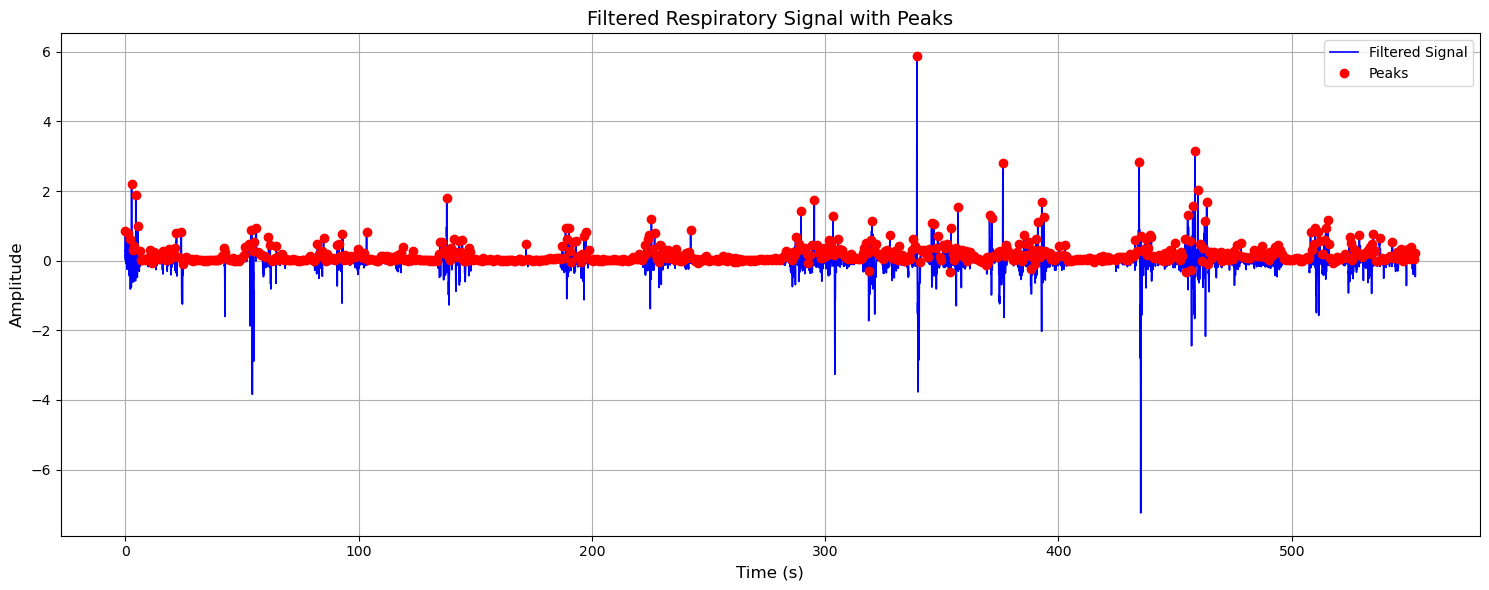

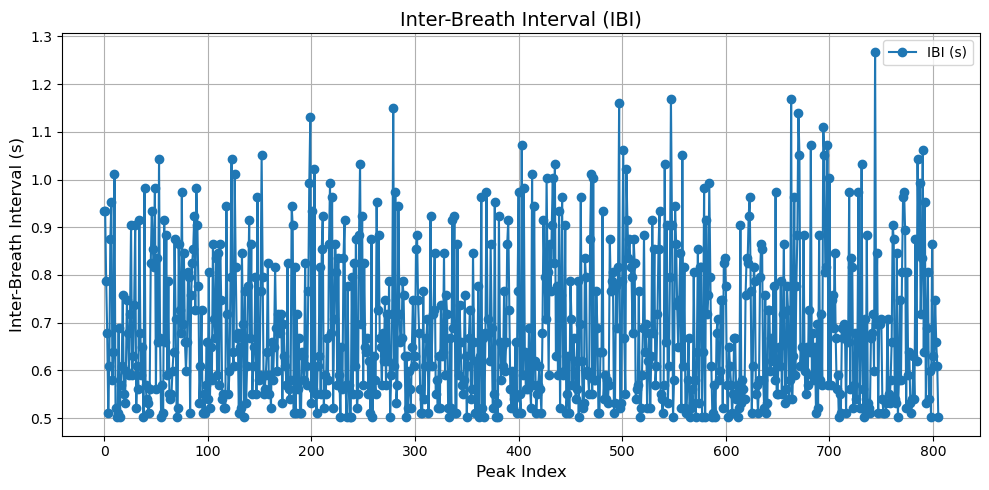

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import neurokit2 as nk
import tdt
from scipy.signal import find_peaks

# Load the TDT block
tdt_file_path = r"E:\resp_test_data\nasal_test-241017-143820"
data = tdt.read_block(tdt_file_path)

# Extract respiratory signal
rsp_signal = data.streams['Resp'].data  # Adjust 'Resp' to match your stream name
srate = data.streams['Resp'].fs  # Sampling rate (Hz)
total_duration = len(rsp_signal) / srate  # Total duration in seconds
time_array = np.linspace(0, total_duration, len(rsp_signal))

# Smooth the respiratory signal
rsp_cleaned = nk.signal_filter(
    rsp_signal,
    lowcut=0.1,   # Low cutoff frequency (Hz)
    highcut=20,   # High cutoff frequency (Hz)
    method="butterworth",  # Filtering method
    sampling_rate=srate,   # Sampling rate of the signal
    order=4                # Filter order
)

# Detect peaks in the signal
peaks, _ = find_peaks(rsp_cleaned, distance=srate * 0.5)  # At least 0.5s between breaths

# Calculate Inter-Breath Intervals (IBI)
ibi = np.diff(peaks) / srate  # Convert sample differences to seconds


# Plot the signal and peaks
plt.figure(figsize=(15, 6))
plt.plot(time_array, rsp_cleaned, label="Filtered Signal", color="blue", linewidth=1.2)
plt.plot(time_array[peaks], rsp_cleaned[peaks], 'ro', label="Peaks")  # Mark peaks
plt.xlabel("Time (s)", fontsize=12)
plt.ylabel("Amplitude", fontsize=12)
plt.title("Filtered Respiratory Signal with Peaks", fontsize=14)
plt.legend(loc="upper right")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot the IBI
plt.figure(figsize=(10, 5))
plt.plot(ibi, marker='o', linestyle='-', label="IBI (s)")
plt.xlabel("Peak Index", fontsize=12)
plt.ylabel("Inter-Breath Interval (s)", fontsize=12)
plt.title("Inter-Breath Interval (IBI)", fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()




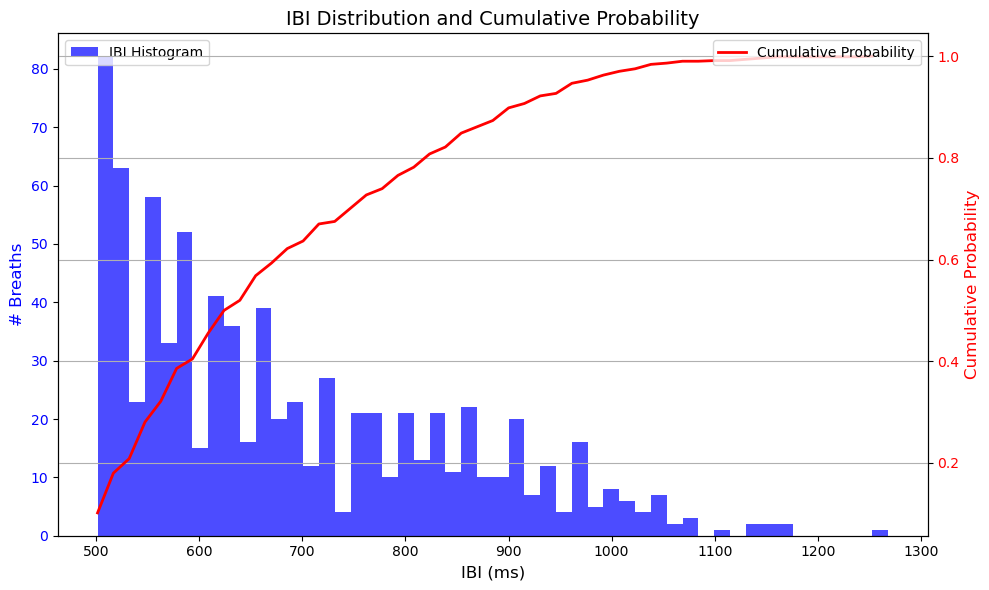

In [26]:
import matplotlib.pyplot as plt
import numpy as np
import neurokit2 as nk
from scipy.signal import find_peaks

# Smooth the respiratory signal (same as before)
rsp_cleaned = nk.signal_filter(
    rsp_signal,
    lowcut=0.1,   # Low cutoff frequency (Hz)
    highcut=20,   # High cutoff frequency (Hz)
    method="butterworth",  # Filtering method
    sampling_rate=srate,   # Sampling rate of the signal
    order=4                # Filter order
)

# Detect peaks in the signal
peaks, _ = find_peaks(rsp_cleaned, distance=srate * 0.5)  # Minimum 0.5s between breaths

# Calculate Inter-Breath Intervals (IBI) in milliseconds
ibi = np.diff(peaks) / srate * 1000  # Convert to milliseconds

# Plot the histogram and cumulative probability
fig, ax1 = plt.subplots(figsize=(10, 6))

# Histogram of IBI
counts, bins, _ = ax1.hist(ibi, bins=50, color='blue', alpha=0.7, label='IBI Histogram')
ax1.set_xlabel("IBI (ms)", fontsize=12)
ax1.set_ylabel("# Breaths", color='blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_title("IBI Distribution and Cumulative Probability", fontsize=14)

# Cumulative Probability (CDF)
ax2 = ax1.twinx()
cumulative = np.cumsum(counts) / sum(counts)  # Normalize to [0, 1]
ax2.plot(bins[:-1], cumulative, color='red', label='Cumulative Probability', linewidth=2)
ax2.set_ylabel("Cumulative Probability", color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')

# Add legends
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")

plt.grid(True)
plt.tight_layout()
plt.show()


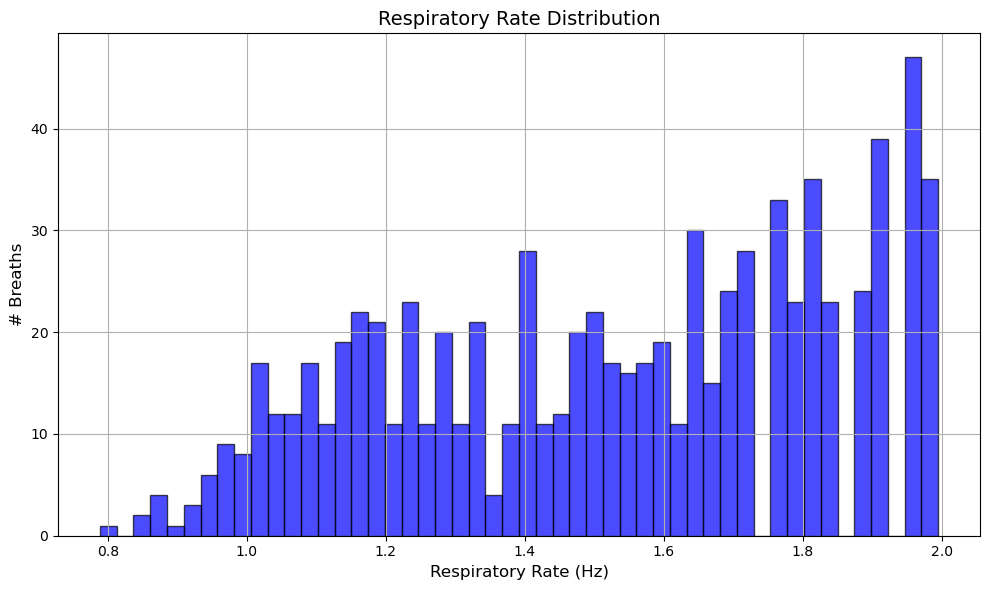

In [27]:
import matplotlib.pyplot as plt
import numpy as np
import neurokit2 as nk
from scipy.signal import find_peaks

# Smooth the respiratory signal (same as before)
rsp_cleaned = nk.signal_filter(
    rsp_signal,
    lowcut=0.1,   # Low cutoff frequency (Hz)
    highcut=20,   # High cutoff frequency (Hz)
    method="butterworth",  # Filtering method
    sampling_rate=srate,   # Sampling rate of the signal
    order=4                # Filter order
)

# Detect peaks in the signal
peaks, _ = find_peaks(rsp_cleaned, distance=srate * 0.5)  # Minimum 0.5s between breaths

# Calculate Inter-Breath Intervals (IBI) and Rate in Hz
ibi = np.diff(peaks) / srate  # Convert to seconds
rate_hz = 1 / ibi  # Calculate respiratory rate in Hz

# Plot the histogram of respiratory rates
plt.figure(figsize=(10, 6))
plt.hist(rate_hz, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Respiratory Rate (Hz)", fontsize=12)
plt.ylabel("# Breaths", fontsize=12)
plt.title("Respiratory Rate Distribution", fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()
